# ⚽ FIFA World Cup 2026 — Modèle Match

**FrenchTeam — Wild Code School — Juin 2026**

---

## 🎯 Architecture du modèle

```
Données historiques (2010 → 2026)
    ↓
6 features essentielles en DIFFÉRENCES (A - B)
    ├── FIFA : écart_brut + écart_carré
    ├── Forme pondérée × Squad × Zone qualif
    ├── Squad : écart_brut + écart_carré
    └── Avantage hôte
    ↓
XGBoost Classifier
    ↓
Prédiction symétrique (moyenne AB + BA)
    ↓
Probabilités : Équipe A gagne / Nul / Équipe B gagne
```

## 📊 Importance des features 
| Catégorie | Poids cible | Description |
|---|---|---|
| FIFA (brut + carré) | ~25% | Classement officiel pondéré |
| Qualité squad (brut + carré) | ~25% | Valeur marchande estimée des joueurs |
| Forme pondérée | ~40% | Résultats récents × adversaires × zone qualif |
| Avantage hôte | ~10% | USA / Canada / Mexique |

## 📦 Étape 1 — Imports

Bibliothèques nécessaires pour la manipulation des données, le modèle ML et la visualisation.

In [1]:
import pandas as pd          # manipulation de tableaux de données
import numpy as np           # calculs numériques (carrés, signes, moyennes)
import os                    # gestion des chemins de fichiers Windows
import matplotlib.pyplot as plt  # visualisation des importances
from xgboost import XGBClassifier          # algorithme de boosting de gradient
from sklearn.model_selection import train_test_split  # séparation train/test
from sklearn.metrics import accuracy_score, classification_report  # évaluation
from sklearn.preprocessing import LabelEncoder  # encodage A_gagne/B_gagne/Nul → 0/1/2
import joblib  # sauvegarde et chargement du modèle entraîné

print('✅ Imports OK')

✅ Imports OK


## 📂 Étape 2 — Chargement des données

Deux datasets sont utilisés :
- `df` : **tous** les matchs internationaux (1872 → 2026) — pour calculer la forme sur l'historique complet
- `df_officiel` : matchs **sans les amicaux** — les amicaux sont moins représentatifs du vrai niveau (rotations, expérimentations)

In [2]:
# Chemin du projet — à adapter si besoin
DOSSIER_PROJET = r'C:\Users\user\Projet3\WorldCup2026'

# Chargement du dataset principal
df = pd.read_csv(os.path.join(DOSSIER_PROJET, 'data', 'results.csv'))
df['date'] = pd.to_datetime(df['date'])  # convertir les dates en format datetime
df = df.dropna(subset=['home_score', 'away_score'])  # supprimer les matchs sans score

# Dataset sans les amicaux (pour le calcul de la forme)
df_officiel = df[df['tournament'] != 'Friendly'].copy()

print(f'Tous les matchs       : {len(df):,}')
print(f'Matchs officiels      : {len(df_officiel):,}')
print(f'Période couverte      : {df["date"].min().date()} → {df["date"].max().date()}')

Tous les matchs       : 49,296
Matchs officiels      : 31,005
Période couverte      : 1872-11-30 → 2026-06-02


## 🔧 Étape 3 — Classement FIFA 2026

Le classement FIFA est l'indicateur le plus fiable du niveau d'une équipe car :
- Il prend en compte le **niveau des adversaires** (battre la France vaut plus que battre Haïti)
- Il pondère l'**importance du tournoi** (CdM > qualifications > amicaux)
- Il est calculé sur l'ensemble des matchs récents

Source : classement officiel FIFA — Avril 2026

In [3]:
# Points FIFA officiels — Avril 2026 (source : FIFA.com)
points_fifa = {
    'France': 1877.32, 'Spain': 1876.40, 'Argentina': 1874.81,
    'England': 1825.97, 'Portugal': 1763.83, 'Brazil': 1761.16,
    'Netherlands': 1757.87, 'Morocco': 1755.87, 'Belgium': 1734.71,
    'Germany': 1730.37, 'Croatia': 1717.07, 'Colombia': 1693.09,
    'Senegal': 1688.99, 'Mexico': 1681.03, 'United States': 1673.13,
    'Uruguay': 1673.07, 'Japan': 1660.43, 'Switzerland': 1649.40,
    'Ecuador': 1619.20, 'Turkey': 1614.55, 'Sweden': 1598.30,
    'Norway': 1590.12, 'Austria': 1578.44, 'South Korea': 1566.23,
    'Tunisia': 1542.18, 'Algeria': 1538.90, 'Ghana': 1521.44,
    'Egypt': 1518.77, 'Saudi Arabia': 1512.33, 'Iran': 1512.00,
    'Australia': 1508.66, 'Iraq': 1489.21, 'Czech Republic': 1488.00,
    'Scotland': 1487.55, 'Paraguay': 1481.33, 'Ivory Coast': 1479.88,
    'South Africa': 1421.34, 'Canada': 1418.77, 'Qatar': 1398.22,
    'Panama': 1392.11, 'Bosnia and Herzegovina': 1388.44,
    'Jordan': 1342.18, 'Uzbekistan': 1338.90, 'DR Congo': 1321.44,
    'New Zealand': 1298.77, 'Haiti': 1245.33, 'Curacao': 1198.22,
    'Cape Verde': 1450.00,
}

# Moyenne utilisée pour les équipes absentes du dictionnaire
MOYENNE_FIFA = np.mean(list(points_fifa.values()))

def get_points_fifa(equipe):
    """Retourne les points FIFA d'une équipe (moyenne si inconnue)."""
    return points_fifa.get(equipe, MOYENNE_FIFA)

print(f'✅ {len(points_fifa)} équipes CdM 2026 chargées')
print(f'Points moyens : {MOYENNE_FIFA:.0f} pts')
print('\nTop 5 :')
for eq, pts in sorted(points_fifa.items(), key=lambda x: -x[1])[:5]:
    print(f'  {eq:<15} {pts:.0f} pts')

✅ 48 équipes CdM 2026 chargées
Points moyens : 1568 pts

Top 5 :
  France          1877 pts
  Spain           1876 pts
  Argentina       1875 pts
  England         1826 pts
  Portugal        1764 pts


## 🔧 Étape 4 — Score de qualité des joueurs

Le classement FIFA mesure les **résultats** mais pas le **talent individuel**.
Un score de 0 à 100 est attribué manuellement à chaque équipe basé sur :
- La valeur marchande Transfermarkt des joueurs
- La présence de stars mondiales
- La profondeur du banc

**Pourquoi cette feature ?**
Elle corrige le biais forme — le Brésil en mauvaise forme reste dangereux grâce à Vinicius Jr, Raphinha, Endrick.

In [4]:
# Score qualité joueurs de 0 (très faible) à 100 (meilleur mondial)
# Basé sur valeur marchande Transfermarkt 2026 + présence de stars
qualite_joueurs = {
    'France': 83.58,
    'Spain': 83.38,
    'Portugal': 82.15,
    'Germany': 81.92,
    'England': 81.46,
    'Argentina': 81.40,
    'Brazil': 80.81,
    'Netherlands': 80.77,
    'Belgium': 78.58,
    'Croatia': 77.38,
    'Colombia': 76.62,
    'Senegal': 76.00,
    'Austria': 75.96,
    'Mexico': 75.81,
    'Ivory Coast': 75.69,
    'Turkey': 75.69,
    'Sweden': 75.38,
    'Norway': 75.27,
    'United States': 75.04,
    'Switzerland': 74.92,
    'Scotland': 74.27,
    'Uruguay': 73.88,
    'Morocco': 73.80,
    'Canada': 73.00,
    'Japan': 72.85,
    'Ecuador': 72.27,
    'Paraguay': 71.54,
    'DR Congo': 70.35,
    'Ghana': 69.77,
    'Czech Republic': 69.27,
    'Bosnia and Herzegovina': 68.42,
    'Algeria': 68.25,
    'Saudi Arabia': 68.10,
    'Cape Verde': 67.65,
    'New Zealand': 67.35,
    'Panama': 67.23,
    'Australia': 66.00,
    'Tunisia': 65.09,
    'Egypt': 63.95,
    'South Africa': 63.12,
    'South Korea': 62.88,
    'Iran': 62.80,
    'Haiti': 62.71,
    'Qatar': 62.67,
    'Curacao': 59.65,
    'Iraq': 59.28,
    'Jordan': 57.67,
    'Uzbekistan': 56.22,
    
}

MOYENNE_QUALITE = np.mean(list(qualite_joueurs.values()))

def get_qualite(equipe):
    """Retourne le score qualité joueurs (moyenne si inconnue)."""
    return qualite_joueurs.get(equipe, MOYENNE_QUALITE)

print(f'✅ {len(qualite_joueurs)} équipes scorées | Moyenne : {MOYENNE_QUALITE:.1f}/100')

✅ 48 équipes scorées | Moyenne : 71.6/100


## 🔧 Étape 5 — Coefficient d'expérience CdM

Une équipe peut avoir une excellente forme en qualification mais sous-performer en phase finale.
La Norvège absente depuis 1998, l'Écosse depuis 1998, l'Australie qui joue surtout contre des équipes OFC/CONCACAF...

**Formule :**
```
forme_ajustée = 0.5 + (forme_brute - 0.5) × coefficient
```
- `coefficient = 1.00` : pas de correction (grandes nations — France, Argentine...)
- `coefficient = 0.52` : correction modérée (ex: Scotland — joueurs PL mais peu de CdM)
- `coefficient = 0.40` : correction forte (ex: Haiti — qualifs CONCACAF trop faciles)
- `coefficient × credibilite_zone` : double correction selon la confédération

In [5]:
coefficient_experience = {
    # Grandes nations — expérience maximale, pas de correction
    'France': 1.00, 'Brazil': 1.00, 'Germany': 1.00,
    'Spain': 1.00, 'Argentina': 1.00, 'England': 1.00,
    'Portugal': 1.00, 'Netherlands': 1.00, 'Belgium': 1.00,
    'Croatia': 1.00, 'Uruguay': 1.00, 'Mexico': 1.00,
    'United States': 1.00,  # pays hôte
    'Canada': 0.95,          # pays hôte, 1 seule participation (1986)
    # Bonne expérience récente
    'Japan': 0.95,      # quarts 2022
    'Morocco': 0.92,    # demi-finale 2022
    'Senegal': 0.92,    # quarts 2022
    'South Korea': 0.92,
    'Colombia': 0.90, 'Switzerland': 0.90,
    'Iran': 0.88, 'Saudi Arabia': 0.88, 'Ghana': 0.88,
    'Ecuador': 0.85, 'Tunisia': 0.85, 'Algeria': 0.85,
    'Austria': 0.85, 'Sweden': 0.85, 'Turkey': 0.85,
    'Egypt': 0.85, 'Paraguay': 0.85, 'Ivory Coast': 0.88,
    'Czech Republic': 0.85,
    'Norway':    0.50,  # absente depuis 1998, forme gonflée qualifs UEFA
    'Scotland':  0.52,  # joueurs PL expérimentés, première CdM depuis 1998
    'Australia': 0.48,  # forme 100% vs équipes OFC très faibles
    'Iraq':      0.70, 'Jordan': 0.60, 'Uzbekistan': 0.60,
    'Panama': 0.68, 'Curacao': 0.35, 'Cape Verde': 0.60,  # Curacao : première CdM, niveau CONCACAF faible
    'New Zealand': 0.60, 'Haiti': 0.40, 'South Africa': 0.72,  # Haiti : qualifs CONCACAF trop faciles
    'Bosnia and Herzegovina': 0.75, 'DR Congo': 0.68, 'Qatar': 0.72,
}
def get_coefficient(equipe):
    """Retourne le coefficient d'expérience CdM (0.80 par défaut)."""
    return coefficient_experience.get(equipe, 0.80)

print('✅ Coefficients expérience chargés')

✅ Coefficients expérience chargés


## 🔧 Étape 6 — Fonctions de calcul

### Forme pondérée avec expérience CdM

Le calcul se fait en 2 étapes :
1. **Forme pondérée par adversaire** : battre la France vaut plus que battre Haïti
2. **Ajustement expérience** : ramène la forme vers 0.5 pour les équipes sans expérience CdM

In [6]:
# Crédibilité de la forme selon la confédération de qualification
# UEFA=1.00 (adversaires forts: Portugal, France...)
# CONMEBOL=0.95 (adversaires forts: Brésil, Argentine...)
# CAF=0.75 (adversaires africains niveau moyen)
# AFC=0.70 (adversaires asiatiques niveau moyen)
# CONCACAF=0.50 (adversaires très faibles: Belize, Barbados, Cayman...)
# OFC=0.40 (adversaires très faibles: Samoa, Vanuatu...)

ZONE_QUALIF = {
    # UEFA
    'France':'UEFA', 'Germany':'UEFA', 'Spain':'UEFA', 'England':'UEFA',
    'Portugal':'UEFA', 'Netherlands':'UEFA', 'Belgium':'UEFA', 'Croatia':'UEFA',
    'Switzerland':'UEFA', 'Austria':'UEFA', 'Denmark':'UEFA', 'Turkey':'UEFA',
    'Scotland':'UEFA', 'Norway':'UEFA', 'Serbia':'UEFA', 'Sweden':'UEFA',
    'Bosnia and Herzegovina':'UEFA', 'Albania':'UEFA', 'Hungary':'UEFA', 'Czech Republic':'UEFA',
    # CONMEBOL
    'Argentina':'CONMEBOL', 'Brazil':'CONMEBOL', 'Colombia':'CONMEBOL',
    'Uruguay':'CONMEBOL', 'Ecuador':'CONMEBOL', 'Paraguay':'CONMEBOL',
    # CAF
    'Morocco':'CAF', 'Senegal':'CAF', 'Egypt':'CAF', 'Ivory Coast':'CAF',
    'Algeria':'CAF', 'Tunisia':'CAF', 'Ghana':'CAF', 'South Africa':'CAF',
    'DR Congo':'CAF', 'Cape Verde':'CAF',
    # CONCACAF
    'United States':'CONCACAF', 'Mexico':'CONCACAF', 'Canada':'CONCACAF',
    'Panama':'CONCACAF', 'Haiti':'CONCACAF', 'Curacao':'CONCACAF',
    # AFC
    'Japan':'AFC', 'South Korea':'AFC', 'Iran':'AFC',
    'Saudi Arabia':'AFC', 'Australia':'AFC', 'Uzbekistan':'AFC',
    'Iraq':'AFC', 'Jordan':'AFC', 'Qatar':'AFC',
    # OFC
    'New Zealand':'OFC',
}

CREDIBILITE_ZONE = {
    'UEFA':     1.00,   # qualifications les plus dures
    'CONMEBOL': 0.95,   # très compétitif
    'CAF':      0.75,   # niveau moyen
    'AFC':      0.70,   # niveau moyen
    'CONCACAF': 0.50,   # adversaires très faibles
    'OFC':      0.40,   # adversaires extrêmement faibles
}

def get_zone(equipe):
    """Retourne la zone de qualification d'une équipe."""
    return ZONE_QUALIF.get(equipe, 'UEFA')  # fallback UEFA (conservateur)

def get_credibilite_zone(equipe):
    """Retourne le coefficient de crédibilité de la zone de qualification."""
    return CREDIBILITE_ZONE.get(get_zone(equipe), 0.75)

print('✅ ZONE_QUALIF et CREDIBILITE_ZONE chargés')
print('\nExemples de crédibilité zone :')
for eq in ['France', 'Scotland', 'Morocco', 'Japan', 'United States', 'Haiti', 'Curacao', 'New Zealand']:
    zone = get_zone(eq)
    cred = get_credibilite_zone(eq)
    print(f'  {eq:<20} {zone:<10} crédibilité = {cred:.2f}')


def calculer_forme(equipe, date, df_officiel, n=5):
    """
    Calcule la forme récente pondérée × coefficient expérience × crédibilité zone.

    Étape 1 — Forme pondérée par adversaire :
    - Récupère les n derniers matchs officiels AVANT la date
    - Pondère chaque match par FIFA_adversaire / 1500
    - Victoire = 3 pts, Nul = 1 pt, Défaite = 0 pt
    - Normalise entre 0 et 1

    Étape 2 — Double ajustement :
    - coefficient_experience : réduit l'effet pour les équipes peu expérimentées
    - credibilite_zone       : réduit l'effet si qualifs contre adversaires faibles
    - coeff_final = coefficient_experience × credibilite_zone
    
    Exemple :
      Haiti     coeff=0.40 × CONCACAF=0.50 → coeff_final=0.20
      Scotland  coeff=0.52 × UEFA=1.00     → coeff_final=0.52
    """
    domicile  = df_officiel[(df_officiel['home_team'] == equipe) & (df_officiel['date'] < date)].tail(n)
    exterieur = df_officiel[(df_officiel['away_team'] == equipe) & (df_officiel['date'] < date)].tail(n)
    matchs    = pd.concat([domicile, exterieur]).sort_values('date').tail(n)

    if len(matchs) == 0:
        return 0.5

    points_total = 0
    poids_total  = 0

    for _, match in matchs.iterrows():
        if match['home_team'] == equipe:
            adversaire = match['away_team']
            victoire   = match['home_score'] > match['away_score']
            nul        = match['home_score'] == match['away_score']
        else:
            adversaire = match['home_team']
            victoire   = match['away_score'] > match['home_score']
            nul        = match['home_score'] == match['away_score']

        poids = get_points_fifa(adversaire) / 1500  # pondération par niveau adversaire

        if victoire:   points_total += 3 * poids
        elif nul:      points_total += 1 * poids
        poids_total += 3 * poids

    forme_brute = points_total / poids_total if poids_total > 0 else 0.5

    # coeff_final = experience × credibilite_zone
    coeff_exp  = get_coefficient(equipe)
    cred_zone  = get_credibilite_zone(equipe)
    coeff_final = coeff_exp * cred_zone

    # Bonus champion CdM récent
    BONUS_CHAMPION = {
        'Argentina': 0.10,
        'France':    0.06,
        'Germany':   0.04,
        'Spain':     0.03,
        'Brazil':    0.02,
    }
    bonus = BONUS_CHAMPION.get(equipe, 0)

    return min(0.5 + (forme_brute - 0.5) * coeff_final + bonus, 1.0)


print('✅ Fonction calculer_forme définie (coeff_experience × credibilite_zone)')
print('\nFormes ajustées (matchs clés) :')
date_test = pd.Timestamp('2026-06-11')
pour_test = ['France', 'Germany', 'England', 'Scotland', 'Haiti', 'Curacao',
             'Brazil', 'Morocco', 'Japan', 'United States', 'New Zealand']
print(f'{"Équipe":<20} {"Zone":<10} {"Cred":>5} {"CoeffExp":>9} {"CoeffFin":>9} {"Brute":>7} {"Ajustée":>8}')
print('─' * 75)
for eq in pour_test:
    domicile  = df_officiel[(df_officiel['home_team'] == eq) & (df_officiel['date'] < date_test)].tail(5)
    exterieur = df_officiel[(df_officiel['away_team'] == eq) & (df_officiel['date'] < date_test)].tail(5)
    matchs_t  = pd.concat([domicile, exterieur]).sort_values('date').tail(5)
    if len(matchs_t) > 0:
        pts = sum_p = 0
        for _, m in matchs_t.iterrows():
            adv = m['away_team'] if m['home_team']==eq else m['home_team']
            v   = (m['home_score']>m['away_score']) if m['home_team']==eq else (m['away_score']>m['home_score'])
            n_  = m['home_score']==m['away_score']
            p   = get_points_fifa(adv)/1500
            if v: pts+=3*p
            elif n_: pts+=1*p
            sum_p+=3*p
        f_brute = pts/sum_p if sum_p>0 else 0.5
    else:
        f_brute = 0.5
    f_adj      = calculer_forme(eq, date_test, df_officiel)
    coeff_e    = get_coefficient(eq)
    cred_z     = get_credibilite_zone(eq)
    coeff_fin  = coeff_e * cred_z
    zone       = get_zone(eq)
    print(f'{eq:<20} {zone:<10} {cred_z:>5.2f} {coeff_e:>9.2f} {coeff_fin:>9.3f} {f_brute:>6.0%} {f_adj:>8.0%}')


✅ ZONE_QUALIF et CREDIBILITE_ZONE chargés

Exemples de crédibilité zone :
  France               UEFA       crédibilité = 1.00
  Scotland             UEFA       crédibilité = 1.00
  Morocco              CAF        crédibilité = 0.75
  Japan                AFC        crédibilité = 0.70
  United States        CONCACAF   crédibilité = 0.50
  Haiti                CONCACAF   crédibilité = 0.50
  Curacao              CONCACAF   crédibilité = 0.50
  New Zealand          OFC        crédibilité = 0.40
✅ Fonction calculer_forme définie (coeff_experience × credibilite_zone)

Formes ajustées (matchs clés) :
Équipe               Zone        Cred  CoeffExp  CoeffFin   Brute  Ajustée
───────────────────────────────────────────────────────────────────────────
France               UEFA        1.00      1.00     1.000    87%      93%
Germany              UEFA        1.00      1.00     1.000   100%     100%
England              UEFA        1.00      1.00     1.000   100%     100%
Scotland             UEF

## 🏗️ Étape 7 — Construction du dataset d'entraînement

### Principe des features en DIFFÉRENCES

Pour un match A vs B, on calcule toujours `valeur_A - valeur_B` :
- Résultat positif = A est meilleure
- Résultat négatif = B est meilleure
- Proche de 0 = niveau égal

Cela garantit la **symétrie** : France vs Argentine = Argentine vs France inversé.

### Les 2 features FIFA
- `écart_fifa_brut` : différence brute (sensible aux petits écarts)
- `écart_fifa_carré` : au carré × signe → **amplifie les grands écarts**
  - France vs Haïti : écart 632 → carré 39.9 (signal très fort)
  - France vs Argentine : écart 3 → carré 0.001 (signal quasi nul)


### La feature forme × qualité
`écart_forme_pondérée = (forme_A × qualité_A) - (forme_B × qualité_B)`

Exemple Brésil vs Haïti :
- Brésil : forme 48% × qualité 0.92 = **0.44**
- Haïti  : forme 53% × qualité 0.08 = **0.04** ← réduit par CONCACAF=0.50
→ Brésil largement devant malgré sa forme difficile ✅

### Les 2 features Qualité
- `écart_qualite` : différence brute
- `écart_qualite_carré` : amplifie les grands écarts


In [7]:
# Filtrer les matchs officiels depuis 2010 (football moderne, sans amicaux)
df_entrainement = df[
    (df['date'] >= '2010-01-01') &      # depuis 2010 = football moderne
    (df['tournament'] != 'Friendly')     # exclure les amicaux
].copy().reset_index(drop=True)

print(f'Matchs d entraînement : {len(df_entrainement):,}')

# Pays hôtes — avantage de jouer à domicile
pays_hotes = ['United States', 'Canada', 'Mexico']

lignes = []  # liste qui contiendra toutes les lignes du dataset
print('Construction du dataset (3-5 min)...')

for i, match in df_entrainement.iterrows():
    equipe_a = match['home_team']   # équipe qui jouait à domicile
    equipe_b = match['away_team']   # équipe qui jouait à l'extérieur
    date     = match['date']

    # Calcul des formes AVANT le match (évite d'utiliser le futur)
    forme_a = calculer_forme(equipe_a, date, df_officiel)
    forme_b = calculer_forme(equipe_b, date, df_officiel)

    # Points FIFA et qualité joueurs
    pts_a      = get_points_fifa(equipe_a)
    pts_b      = get_points_fifa(equipe_b)
    ecart_fifa = pts_a - pts_b

    qual_a = get_qualite(equipe_a) / 100  # normaliser entre 0 et 1
    qual_b = get_qualite(equipe_b) / 100
    ecart_qualite = qual_a - qual_b

    # Avantage hôte CdM 2026
    if equipe_a in pays_hotes:   hote = 0.5   # A joue à domicile
    elif equipe_b in pays_hotes: hote = -0.5  # B joue à domicile
    else:                         hote = 0.0   # terrain neutre

    # Variable cible : résultat du point de vue de équipe_a
    if   match['home_score'] > match['away_score']: resultat = 'A_gagne'
    elif match['home_score'] < match['away_score']: resultat = 'B_gagne'
    else:                                            resultat = 'Nul'

    lignes.append({
        # ─── FEATURES FIFA ───────────────────────────────────────
        'ecart_fifa_brut':      ecart_fifa,                          # différence brute de points
        'ecart_fifa_carre':     (ecart_fifa/100)**2 * np.sign(ecart_fifa),  # amplifie grands écarts

        # ─── FEATURE FORME × QUALITÉ ─────────────────────────────
        'ecart_forme_ponderee': (forme_a * qual_a) - (forme_b * qual_b),

        # ─── FEATURES QUALITÉ JOUEURS ────────────────────────────
        'ecart_qualite':        ecart_qualite,                       # différence brute qualité
        'ecart_qualite_carre':  ecart_qualite**2 * np.sign(ecart_qualite),  # amplifie grands écarts

        # ─── FEATURE CONTEXTE ────────────────────────────────────
        'avantage_hote':        hote,                                # +0.5 / 0 / -0.5

        'resultat': resultat
    })

    if i % 1000 == 0 and i > 0:
        print(f'  {i:,}/{len(df_entrainement):,} matchs traités...')

df_dataset = pd.DataFrame(lignes)
print(f'\n✅ Dataset : {len(df_dataset):,} matchs')
print('Distribution des résultats :')
print(df_dataset['resultat'].value_counts())

Matchs d entraînement : 10,732
Construction du dataset (3-5 min)...
  1,000/10,732 matchs traités...
  2,000/10,732 matchs traités...
  3,000/10,732 matchs traités...
  4,000/10,732 matchs traités...
  5,000/10,732 matchs traités...
  6,000/10,732 matchs traités...
  7,000/10,732 matchs traités...
  8,000/10,732 matchs traités...
  9,000/10,732 matchs traités...
  10,000/10,732 matchs traités...

✅ Dataset : 10,732 matchs
Distribution des résultats :
resultat
A_gagne    5096
B_gagne    3285
Nul        2351
Name: count, dtype: int64


## 🤖 Étape 8 — Entraînement du modèle

### Pourquoi XGBoost ?
XGBoost (eXtreme Gradient Boosting) construit des arbres de décision séquentiellement,
chacun corrigeant les erreurs du précédent. Il est particulièrement adapté aux données tabulaires.

### Stratégie train/test
- 80% des matchs → **entraînement** (le modèle apprend les patterns)
- 20% des matchs → **test** (évaluation sur des données jamais vues)
- `stratify` → garantit la même proportion V/N/D dans les deux ensembles

### Accuracy attendue
55-60% est un **excellent score** pour prédire du football.
Même les meilleurs modèles professionnels dépassent rarement 65%.

In [8]:
# Noms des features utilisées par le modèle (en français)
FEATURES = [
    'ecart_fifa_brut',      # écart FIFA brut
    'ecart_fifa_carre',     # écart FIFA au carré — amplifie les grands écarts
    'ecart_forme_ponderee', # forme × qualité (intègre crédibilité zone de qualification)
    'ecart_qualite',        # écart qualité joueurs
    'ecart_qualite_carre',  # qualité au carré — amplifie les grands écarts
    'avantage_hote',        # avantage pays hôte USA / Canada / Mexico
]

X = df_dataset[FEATURES]     # matrice des features
y = df_dataset['resultat']   # vecteur cible

# Encoder les labels : A_gagne=0, B_gagne=1, Nul=2
encodeur_resultat = LabelEncoder()
y_encode = encodeur_resultat.fit_transform(y)
print(f'Classes : {dict(zip(encodeur_resultat.classes_, range(3)))}')

# Séparation 80/20 avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encode,
    test_size=0.2,
    random_state=42,    # graine fixe pour reproductibilité
    stratify=y_encode   # même proportion V/N/D dans train et test
)
print(f'Entraînement : {len(X_train):,} matchs | Test : {len(X_test):,} matchs')

Classes : {'A_gagne': 0, 'B_gagne': 1, 'Nul': 2}
Entraînement : 8,585 matchs | Test : 2,147 matchs


📊 Poids par classe :
  A_gagne      :  4076 matchs  → poids = 1.0
  B_gagne      :  2628 matchs  → poids = 1.2
  Nul          :  1881 matchs  → poids = 1.4

🔍 GridSearchCV en cours (8-12 min)...
Fitting 3 folds for each of 64 candidates, totalling 192 fits

✅ Meilleurs paramètres trouvés :
  colsample_bytree       : 0.8
  learning_rate          : 0.03
  max_depth              : 4
  min_child_weight       : 1
  n_estimators           : 300
  subsample              : 0.8
  Accuracy CV            : 50.36%

✅ Modèle XGBoost + calibration isotonique prêt
✅ Accuracy : 54.45%
(55-60% = excellent pour football)

              precision    recall  f1-score   support

     A_gagne       0.60      0.76      0.67      1020
     B_gagne       0.47      0.59      0.52       657
         Nul       0.15      0.01      0.01       470

    accuracy                           0.54      2147
   macro avg       0.41      0.45      0.40      2147
weighted avg       0.46      0.54      0.48      2147



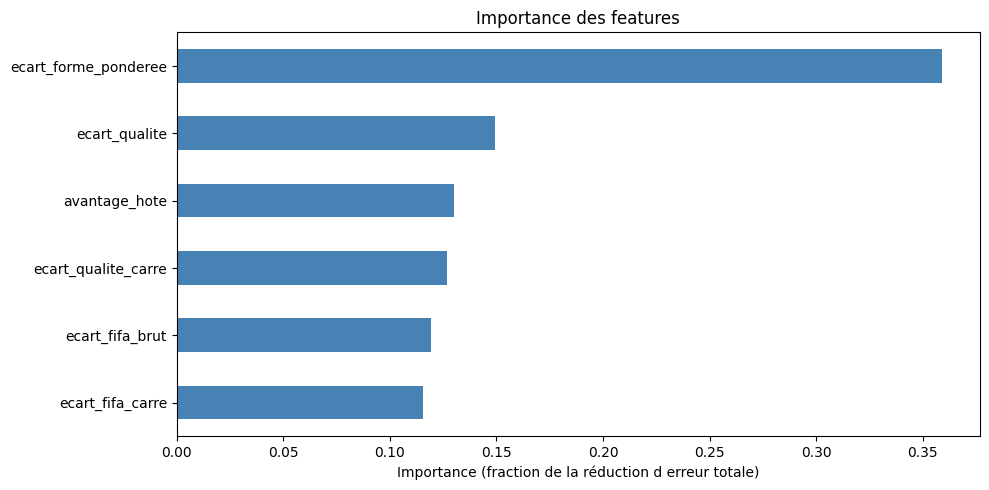


📊 Importance par catégorie :
  Classement FIFA      : 23.5%
  Qualité joueurs      : 27.6%
  Forme récente        : 35.9%
  Avantage hôte        : 13.0%

  ✅ Ratio FIFA+Qualité : 51.1%  (cible > 50%)
  ✅ Forme             : 35.9%  (cible < 40%)


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# ── Étape 1 : Poids manuels calibrés football ────────────
# Rationale :
#   A_gagne = 5096 matchs (majorité) → poids 1.0 (référence)
#   B_gagne = 3285 matchs            → poids 1.2 (légèrement avantagé)
#   Nul     = 2351 matchs (minorité) → poids 1.4 (encouragé sans excès)
POIDS_CLASSES = {0: 1.0, 1: 1.2, 2: 1.4}  # 0=A_gagne, 1=B_gagne, 2=Nul

poids_echantillons = np.array([POIDS_CLASSES[y] for y in y_train])  # un poids par ligne

print('📊 Poids par classe :')
classes_noms = encodeur_resultat.classes_
for idx, nom in enumerate(classes_noms):
    n = (y_train == idx).sum()
    print(f'  {nom:<12} : {n:>5} matchs  → poids = {POIDS_CLASSES[idx]:.1f}')

# ── Étape 2 : GridSearchCV ──────────────────────────────
# min_child_weight : évite les feuilles avec trop peu d'exemples (régularise)
print('\n🔍 GridSearchCV en cours (8-12 min)...')

grille_params = {
    'n_estimators':      [300, 500],
    'max_depth':         [4, 5],
    'learning_rate':     [0.03, 0.05],
    'subsample':         [0.8, 0.9],
    'colsample_bytree':  [0.8, 1.0],
    'min_child_weight':  [1, 3],       # régularisation (évite feuilles trop petites)
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = grille_params,
    cv         = 3,           # 3-fold cross-validation
    scoring    = 'accuracy',
    n_jobs     = -1,          # tous les CPU disponibles
    verbose    = 1
)

grid_search.fit(X_train, y_train, sample_weight=poids_echantillons)

print(f'\n✅ Meilleurs paramètres trouvés :')
for param, val in grid_search.best_params_.items():
    print(f'  {param:<22} : {val}')
print(f'  Accuracy CV            : {grid_search.best_score_:.2%}')

# ── Étape 3 : Réentraînement avec les meilleurs params ────
modele_xgb = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    eval_metric='mlogloss'
)
modele_xgb.fit(X_train, y_train, sample_weight=poids_echantillons)

# ── Étape 4 : Calibration isotonique ─────────────────────
modele = CalibratedClassifierCV(modele_xgb, method='isotonic', cv=5)
modele.fit(X_train, y_train, sample_weight=poids_echantillons)

print('\n✅ Modèle XGBoost + calibration isotonique prêt')

predictions = modele.predict(X_test)

# ── Évaluation ────────────────────────────────────────────
print(f'✅ Accuracy : {accuracy_score(y_test, predictions):.2%}')
print('(55-60% = excellent pour football)')
print()
print(classification_report(y_test, predictions, target_names=encodeur_resultat.classes_))

# ── Graphique importance features ─────────────────────────
importances = pd.Series(modele_xgb.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Importance des features')
plt.xlabel('Importance (fraction de la réduction d erreur totale)')
plt.tight_layout()
plt.show()

# ── Résumé catégories ─────────────────────────────────────
total_fifa  = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'fifa'       in f)
total_qual  = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'qualite'    in f)
total_forme = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'forme'      in f)
total_hote  = modele_xgb.feature_importances_[FEATURES.index('avantage_hote')]
print('\n📊 Importance par catégorie :')
print(f'  Classement FIFA      : {total_fifa:.1%}')
print(f'  Qualité joueurs      : {total_qual:.1%}')
print(f'  Forme récente        : {total_forme:.1%}')
print(f'  Avantage hôte        : {total_hote:.1%}')
print(f'\n  ✅ Ratio FIFA+Qualité : {total_fifa+total_qual:.1%}  (cible > 50%)')
print(f'  ✅ Forme             : {total_forme:.1%}  (cible < 40%)')


## 🔮 Étape 9 — Prédiction symétrique

### Pourquoi la symétrie est importante
Dans le dataset, `equipe_a` est toujours l'ancienne `home_team`.
Cela crée un léger biais : `equipe_a` gagne plus souvent dans les données.

**Solution** : calculer la prédiction dans les 2 sens et faire la moyenne :
1. France vs Argentine → P(France gagne)
2. Argentine vs France → P(Argentine gagne) = 1 - P(France gagne)
3. Moyenne → résultat identique quel que soit l'ordre ✅

In [10]:
# Index des classes pour la symétrie
CLASSES  = list(encodeur_resultat.classes_)  # ['A_gagne', 'B_gagne', 'Nul']
IDX_A    = CLASSES.index('A_gagne')  # index de la victoire A
IDX_B    = CLASSES.index('B_gagne')  # index de la victoire B
IDX_N    = CLASSES.index('Nul')      # index du nul

PAYS_HOTES   = ['United States', 'Canada', 'Mexico']
DATE_TOURNOI = pd.Timestamp('2026-06-11')  # début de la CdM 2026


def construire_features(equipe_a, equipe_b):
    """Construit le vecteur de 6 features pour un match equipe_a vs equipe_b."""
    forme_a   = calculer_forme(equipe_a, DATE_TOURNOI, df_officiel)
    forme_b   = calculer_forme(equipe_b, DATE_TOURNOI, df_officiel)
    pts_a     = get_points_fifa(equipe_a)
    pts_b     = get_points_fifa(equipe_b)
    ecart     = pts_a - pts_b
    qual_a    = get_qualite(equipe_a) / 100
    qual_b    = get_qualite(equipe_b) / 100
    ecart_q   = qual_a - qual_b
    if equipe_a in PAYS_HOTES:   hote = 0.5
    elif equipe_b in PAYS_HOTES: hote = -0.5
    else:                         hote = 0.0
    return pd.DataFrame([{
        'ecart_fifa_brut':      ecart,
        'ecart_fifa_carre':     (ecart/100)**2 * np.sign(ecart),
        'ecart_forme_ponderee': (forme_a * qual_a) - (forme_b * qual_b),
        'ecart_qualite':        ecart_q,
        'ecart_qualite_carre':  ecart_q**2 * np.sign(ecart_q),
        'avantage_hote':        hote,
    }]), pts_a, pts_b, forme_a, forme_b, int(qual_a*100), int(qual_b*100)


def corriger_coherence(p_a, p_n, p_b, pts_a, pts_b, qual_a, qual_b):
    """
    Correction de cohérence post-XGBoost.

    Activée UNIQUEMENT si :
      1. FIFA et qualité pointent dans le même sens (même favoris)
      2. Le modèle XGBoost contredit les deux indicateurs

    Force de correction proportionnelle aux deux écarts.
    Préserve un minimum de 8% pour le perdant et 10% pour le nul.
    """
    ecart_fifa = pts_a - pts_b
    ecart_qual = qual_a - qual_b  # déjà en 0-100

    # Condition 1 : cohérence FIFA + qualité
    if not ((ecart_fifa > 0 and ecart_qual > 0) or
            (ecart_fifa < 0 and ecart_qual < 0)):
        return p_a, p_n, p_b  # désaccord → laisser le modèle décider

    a_doit_gagner = (ecart_fifa > 0)

    # Condition 2 : le modèle est incohérent
    if not ((a_doit_gagner and p_b > p_a) or
            (not a_doit_gagner and p_a > p_b)):
        return p_a, p_n, p_b  # modèle déjà cohérent → rien à faire

    # Calcul de la force de correction (0 → 0.45 max)
    force_fifa = min(1.0, abs(ecart_fifa) / 400)   # plafond à 400 pts FIFA
    force_qual = min(1.0, abs(ecart_qual) / 60)    # plafond à 60/100 pts qualité
    force = 0.45 * (force_fifa * 0.60 + force_qual * 0.40)

    if a_doit_gagner:
        p_a_new = p_a + force
        p_b_new = max(0.08, p_b - force * 0.85)
        p_n_new = max(0.10, p_n - force * 0.15)
    else:
        p_b_new = p_b + force
        p_a_new = max(0.08, p_a - force * 0.85)
        p_n_new = max(0.10, p_n - force * 0.15)

    t = p_a_new + p_n_new + p_b_new
    return p_a_new / t, p_n_new / t, p_b_new / t


def predire_match(equipe_a, equipe_b):
    """
    Prédit le résultat entre deux équipes avec prédiction symétrique.
    Résultat identique quel que soit l'ordre des équipes.
    """
    # Sens 1 : A vs B
    feat_ab, pts_a, pts_b, f_a, f_b, q_a, q_b = construire_features(equipe_a, equipe_b)
    proba_ab = modele.predict_proba(feat_ab)[0]

    # Sens 2 : B vs A (équipes inversées)
    feat_ba, *_ = construire_features(equipe_b, equipe_a)
    proba_ba = modele.predict_proba(feat_ba)[0]

    # Moyenne symétrique des deux prédictions
    p_a = (proba_ab[IDX_A] + proba_ba[IDX_B]) / 2
    p_b = (proba_ab[IDX_B] + proba_ba[IDX_A]) / 2
    p_n = (proba_ab[IDX_N] + proba_ba[IDX_N]) / 2

    # Renormaliser pour que la somme = 100%
    total = p_a + p_b + p_n
    p_a /= total; p_b /= total; p_n /= total

    # Correction de cohérence post-modèle
    p_a, p_n, p_b = corriger_coherence(p_a, p_n, p_b, pts_a, pts_b, q_a, q_b)

    # Affichage
    print(f'\n⚽  {equipe_a}  vs  {equipe_b}')
    print(f'    FIFA   : {pts_a:.0f} pts  vs  {pts_b:.0f} pts  (écart {pts_a-pts_b:+.0f})')
    print(f'    Forme  : {f_a:.0%}  vs  {f_b:.0%}  (ajustée expérience CdM)')
    print(f'    Qualité: {q_a}/100  vs  {q_b}/100')
    if equipe_a in PAYS_HOTES: print(f'    🏠 {equipe_a} pays hôte CdM 2026')
    if equipe_b in PAYS_HOTES: print(f'    🏠 {equipe_b} pays hôte CdM 2026')
    print('    ' + '─' * 40)
    for label, prob in [
        (f'{equipe_a} gagne', p_a),
        ('Nul',               p_n),
        (f'{equipe_b} gagne', p_b)
    ]:
        barre = '█' * int(prob * 20)
        print(f'    {label:24} {barre:20} {prob:.1%}')

print('✅ Modèle prêt pour les prédictions')

# ── Fonction principale de prédiction (pour le simulateur de tournoi)
# Retourne (proba_A_gagne, proba_nul, proba_B_gagne)
DATE_T = pd.Timestamp('2026-06-11')
HOTES  = ['United States', 'Canada', 'Mexico']

def probas_match(eq_a, eq_b):
    def features(a, b):
        fa = calculer_forme(a, DATE_T, df_officiel)
        fb = calculer_forme(b, DATE_T, df_officiel)
        pa = get_points_fifa(a); pb = get_points_fifa(b); ef = pa - pb
        qa = get_qualite(a)/100; qb = get_qualite(b)/100; eq_ = qa - qb
        h  = 0.5 if a in HOTES else (-0.5 if b in HOTES else 0.0)
        return pd.DataFrame([{
            'ecart_fifa_brut':      ef,
            'ecart_fifa_carre':     (ef/100)**2 * (1 if ef>=0 else -1),
            'ecart_forme_ponderee': (fa*qa) - (fb*qb),
            'ecart_qualite':        eq_,
            'ecart_qualite_carre':  eq_**2 * (1 if eq_>=0 else -1),
            'avantage_hote':        h,
        }]), pa, pb, int(qa*100), int(qb*100)

    feat_ab, pts_a, pts_b, q_a, q_b = features(eq_a, eq_b)
    feat_ba, *_                      = features(eq_b, eq_a)
    pab = modele.predict_proba(feat_ab)[0]
    pba = modele.predict_proba(feat_ba)[0]
    ia  = CLASSES.index('A_gagne')
    ib  = CLASSES.index('B_gagne')
    in_ = CLASSES.index('Nul')
    pa  = (pab[ia] + pba[ib]) / 2
    pb  = (pab[ib] + pba[ia]) / 2
    pn  = (pab[in_] + pba[in_]) / 2
    t   = pa + pb + pn
    pa /= t; pn /= t; pb /= t
    # Correction cohérence
    pa, pn, pb = corriger_coherence(pa, pn, pb, pts_a, pts_b, q_a, q_b)
    return pa, pn, pb

print('✅ Fonction probas_match() prête')


✅ Modèle prêt pour les prédictions
✅ Fonction probas_match() prête


In [11]:
print('=' * 60)
print('TESTS DE COHÉRENCE')
print('=' * 60)

print('\n--- TEST SYMÉTRIE (résultats identiques dans les 2 sens) ---')
predire_match('France',    'Argentina')
predire_match('Argentina', 'France')

print('\n--- MATCHS AVEC ÉCARTS IMPORTANTS ---')
predire_match('France',   'Norway')     # France doit être favorite
predire_match('Morocco',  'Scotland')   # Maroc doit être favori
predire_match('Brazil',   'Morocco')    # Brésil doit être favori
predire_match('Australia','Turkey')     # Turquie doit être favorite

print('\n--- VALIDATION DES MATCHS DÉJÀ CORRECTS ---')
predire_match('Brazil',        'Canada')
predire_match('Germany',       'Mexico')
predire_match('United States', 'Iran')
predire_match('Argentina',     'Saudi Arabia')
predire_match('Spain',         'Uruguay')
predire_match('England',       'Croatia')
predire_match('France',        'Haiti')
predire_match('Netherlands',   'Japan')
predire_match('Norway',        'Senegal')

TESTS DE COHÉRENCE

--- TEST SYMÉTRIE (résultats identiques dans les 2 sens) ---

⚽  France  vs  Argentina
    FIFA   : 1877 pts  vs  1875 pts  (écart +3)
    Forme  : 93%  vs  76%  (ajustée expérience CdM)
    Qualité: 83/100  vs  81/100
    ────────────────────────────────────────
    France gagne             █████████            48.2%
    Nul                      █████                29.2%
    Argentina gagne          ████                 22.5%

⚽  Argentina  vs  France
    FIFA   : 1875 pts  vs  1877 pts  (écart -3)
    Forme  : 76%  vs  93%  (ajustée expérience CdM)
    Qualité: 81/100  vs  83/100
    ────────────────────────────────────────
    Argentina gagne          ████                 22.5%
    Nul                      █████                29.2%
    France gagne             █████████            48.2%

--- MATCHS AVEC ÉCARTS IMPORTANTS ---

⚽  France  vs  Norway
    FIFA   : 1877 pts  vs  1590 pts  (écart +287)
    Forme  : 93%  vs  75%  (ajustée expérience CdM)
    Qualité: 

## 💾 Étape 10 — Sauvegarde du modèle final

On sauvegarde le modèle et l'encodeur pour les réutiliser dans le simulateur de tournoi.

In [12]:
dossier_modeles = os.path.join(DOSSIER_PROJET, 'models')

# Sauvegarder le modèle XGBoost entraîné
joblib.dump(modele,             os.path.join(dossier_modeles, 'modele_niveau1_final.pkl'))

# Sauvegarder l'encodeur (A_gagne/B_gagne/Nul → 0/1/2)
joblib.dump(encodeur_resultat,  os.path.join(dossier_modeles, 'encodeur_cible.pkl'))

print('✅ Modèle sauvegardé !')
print(f'📁 {dossier_modeles}')
print(f'\n📊 Résumé du modèle :')
print(f'  Accuracy           : {accuracy_score(y_test, predictions):.2%}')
print(f'  Features           : {len(FEATURES)}')
print(f'  Matchs entraîn.    : {len(X_train):,}')
print(f'  Classement FIFA    : {total_fifa:.1%} importance')
print(f'  Qualité joueurs    : {total_qual:.1%} importance')
print(f'  Forme récente      : {total_forme:.1%} importance')
print(f'  Avantage hôte      : {total_hote:.1%} importance')

✅ Modèle sauvegardé !
📁 C:\Users\user\Projet3\WorldCup2026\models

📊 Résumé du modèle :
  Accuracy           : 54.45%
  Features           : 6
  Matchs entraîn.    : 8,585
  Classement FIFA    : 23.5% importance
  Qualité joueurs    : 27.6% importance
  Forme récente      : 35.9% importance
  Avantage hôte      : 13.0% importance
